# Visits to American National Parks — Exploratory Data Analysis

**SI 699 mini project · branch `Sikandar`**

This notebook explores the National Park Service's by-month visitor-use dataset
(1979–2023, 63 parks) to identify a defensible, non-obvious claim about *how*
people visit national parks, and to back that claim with statistics rather than
a single chart.

**Data source:** NPS Visitor Use Statistics, by-month extract, distributed via
[Responsible Datasets in Context](https://www.responsible-datasets-in-context.com/posts/np-data/)
(Walsh et al.). See the accompanying [data essay](https://www.responsible-datasets-in-context.com/posts/np-data/?tab=data-essay)
for collection methodology and known caveats, cited throughout this notebook.

## Contents
1. [Data and methodology](#Data-and-methodology)
2. [Finding 1 — Visitation is de-seasonalizing](#Finding-1)
3. [Finding 2 — Overnight camping is declining relative to visits](#Finding-2)
4. [Supporting context — seasonal typology and the 2020 shock](#Supporting-context)
5. [Limitations and generalizability](#Limitations)
6. [Assignment response — claim, analysis, elaboration, discussion](#Assignment-response)
7. [Potential topics for further exploration](#Further-topics)


## Setup

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import npdata
import npviz

npviz.apply_style()
pd.set_option("display.max_columns", 50)

import matplotlib, statsmodels, scipy
print(f"pandas {pd.__version__} | numpy {np.__version__} | matplotlib {matplotlib.__version__} | "
      f"statsmodels {statsmodels.__version__} | scipy {scipy.__version__}")


pandas 2.2.3 | numpy 2.1.3 | matplotlib 3.10.0 | statsmodels 0.14.4 | scipy 1.15.3


*Reusable plotting and analysis code lives in [`src/npviz.py`](../src/npviz.py)
and [`src/npdata.py`](../src/npdata.py) rather than inline in this notebook, so the
same styling and statistical helpers are used consistently across every figure
(see `requirements.txt` for exact package versions to reproduce this analysis).*

## Data and methodology <a id='Data-and-methodology'></a>

In [2]:
df = npdata.load_by_month()
print(f"{df.shape[0]:,} rows · {df.ParkName.nunique()} parks · {df.Year.min()}–{df.Year.max()}")
df.head(3)


33,395 rows · 63 parks · 1979–2023


,ParkName,UnitCode,ParkType,Region,State,Year,Month,RecreationVisits,NonRecreationVisits,TentCampers,RVCampers,Backcountry,Date,ZeroMonth,ZeroYear
0,Acadia NP,ACAD,National Park,Northeast,ME,1979,1,6011,15252,102,13,0,1979-01-01,False,False
1,Acadia NP,ACAD,National Park,Northeast,ME,1979,2,5243,13776,53,8,0,1979-02-01,False,False
2,Acadia NP,ACAD,National Park,Northeast,ME,1979,3,11165,15252,176,37,0,1979-03-01,False,False


**Data dictionary:**

In [3]:
npdata.data_dictionary()

,Meaning
Field,
ParkName,Park name as published by NPS (63 parks design...
UnitCode,Four-letter NPS unit code (stable key)
ParkType,Constant: 'National Park'
Region,NPS administrative region (6 values)
State,Primary state (30 values); multi-state parks l...
Year / Month,Calendar year (1979-2023) and month (1-12)
RecreationVisits,Counted recreation visits (the headline visita...
NonRecreationVisits,"Commuter, through-traffic, staff, research visits"
TentCampers / RVCampers,"Overnight stays in front-country campgrounds, ..."


**Cleaning applied** (see `npdata.load_by_month`): stripped a UTF-8 BOM and
trailing whitespace from text fields (e.g. `"Northeast "` → `"Northeast"`);
added a month-start `Date` column; flagged individual zero-visit months
(`ZeroMonth`) and any park-year containing one (`ZeroYear`) rather than
dropping them, since the data essay documents that some zeros reflect
non-reporting, not true absence of visitors (e.g. Kobuk Valley NP, 2014–2015).
No rows were removed.

**Coverage check** — is the panel complete enough to trend on?

In [4]:
coverage = df.groupby("ParkName")["Date"].agg(n_months="count", first="min", last="max")
coverage["expected"] = ((coverage["last"].dt.year - coverage["first"].dt.year) * 12
                         + (coverage["last"].dt.month - coverage["first"].dt.month) + 1)
coverage["missing_months"] = coverage["expected"] - coverage["n_months"]
print(f"Parks with any missing month: {(coverage.missing_months > 0).sum()} / {len(coverage)}")
coverage.sort_values("missing_months", ascending=False).head(5)


Parks with any missing month: 3 / 63


,n_months,first,last,expected,missing_months
ParkName,,,,,
National Park of American Samoa,240,2002-01-01,2023-12-01,264,24
Katmai NP & PRES,528,1979-01-01,2023-12-01,540,12
Channel Islands NP,539,1979-01-01,2023-12-01,540,1
Acadia NP,540,1979-01-01,2023-12-01,540,0
Petrified Forest NP,540,1979-01-01,2023-12-01,540,0


In [5]:
zero_park_years = df[df.ZeroMonth].groupby("ParkName")["Year"].nunique().sort_values(ascending=False)
print(f"{len(zero_park_years)} parks have >=1 zero-visit month; "
      f"{df.ZeroYear.sum() / len(df):.1%} of rows fall in a park-year containing one.")
zero_park_years.head(6)


35 parks have >=1 zero-visit month; 3.9% of rows fall in a park-year containing one.


ParkName
Gates of the Arctic NP & PRES    21
Katmai NP & PRES                 18
Isle Royale NP                   11
North Cascades NP                11
Lake Clark NP & PRES              6
Kenai Fjords NP                   5
Name: Year, dtype: int64

The panel has no gaps *inside* any park's own reporting window (one park is
one month short out of 33,395 rows), but the coverage table above measures
each park from its own first to last year, so it does not flag parks that
enter the file late. Eight do: the five large Alaska parks and preserves
begin in 1982, New River Gorge in 1984, Congaree in 1985 and the National
Park of American Samoa in 2002. Together they account for 1.8% of all
recorded visits, and the [balanced-panel check](#Assignment-response) in the
Assignment response refits the headline trend on only the 55 parks observed
across the whole 1979–2023 window, where it is unchanged.

Zero-visit months are concentrated in a handful of remote Alaska/Pacific
parks with known reporting gaps — consistent with the data essay's caveats.
Both findings below are checked with and without those park-years
(**Robustness** cells) and the conclusions do not change, so we keep the
full panel rather than dropping data that may simply be under-reported
rather than truly zero.


## Finding 1 — Visitation is de-seasonalizing <a id='Finding-1'></a>

**Metric.** For each year, the share of that year's national recreation
visits occurring in June–August (the traditional "peak season"). We fit an
ordinary-least-squares trend of this share on year, with Newey–West
(HAC) standard errors to allow for serial correlation across adjacent years
(see `npdata.trend`).

In [6]:
national_matrix = npdata.monthly_matrix(df, ["Year"])
summer = npdata.summer_share(national_matrix)
fit = npdata.trend(summer)
print(f"Slope: {fit.slope:+.3f} share-points per decade "
      f"(95% CI {fit.ci_low:+.3f} to {fit.ci_high:+.3f}), p = {fit.p_value:.2e}, n = {int(fit.n)} years")


Slope: -0.016 share-points per decade (95% CI -0.020 to -0.012), p = 1.50e-15, n = 45 years


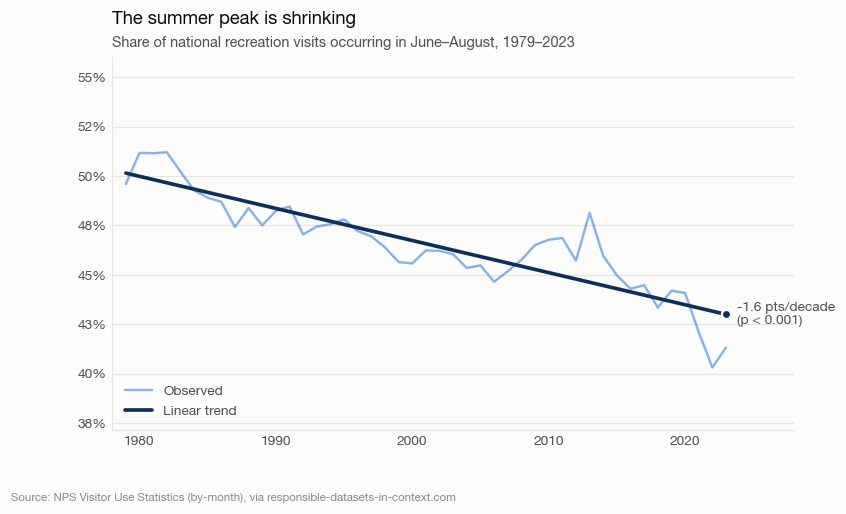

In [7]:
fig, ax = npviz.new_figure(8, 4.4)
years = summer.index.to_numpy(dtype=float)
pred = fit.slope / 10 * (years - years.mean()) + summer.mean()
ax.fill_between(years, pred - 0.05, pred + 0.05, alpha=0)  # keep autoscale consistent
ax.plot(summer.index, summer.values, color=npviz.BLUE, lw=1.6, alpha=0.55, label="Observed")
ax.plot(years, pred, color=npviz.DARK_BLUE, lw=2.4, label="Linear trend")
npviz.pct_axis(ax)
npviz.end_label(ax, years[-1], pred[-1], f"{fit.slope*100:+.1f} pts/decade\n(p < 0.001)",
                 color=npviz.DARK_BLUE, dx=0.8)
ax.set_xlim(1978, 2028)
npviz.title(ax, "The summer peak is shrinking",
            "Share of national recreation visits occurring in June–August, 1979–2023")
ax.legend(loc="lower left")
npviz.source_note(fig)
npviz.save(fig, "01_summer_share_trend")
plt.show()


### Robustness checks

In [8]:
checks = {}
checks["Main (visit-weighted national share)"] = fit

# (a) unweighted across parks -- is this a few huge parks, or broad-based?
park_year_matrix = npdata.monthly_matrix(df, ["ParkName", "Year"])
park_share = npdata.summer_share(park_year_matrix).dropna()
unweighted = park_share.groupby(level="Year").mean()
checks["Unweighted mean across the 63 parks"] = npdata.trend(unweighted)

# (b) excluding the COVID-disrupted years
checks["Excluding 2020-2021"] = npdata.trend(summer.drop(index=[2020, 2021]))

# (c) park-specific peak season instead of a fixed calendar summer
checks["Park-specific best 3 consecutive months"] = npdata.trend(npdata.peak3_share(national_matrix))

pd.DataFrame(checks).T[["slope", "ci_low", "ci_high", "p_value", "n"]].round(4)


,slope,ci_low,ci_high,p_value,n
Main (visit-weighted national share),-0.0163,-0.0202,-0.0123,0.0,45.0
Unweighted mean across the 63 parks,-0.0096,-0.0134,-0.0058,0.0,45.0
Excluding 2020-2021,-0.0160,-0.0204,-0.0117,0.0,43.0
Park-specific best 3 consecutive months,-0.0159,-0.0199,-0.0118,0.0,45.0


The trend survives every robustness check: it's not an artifact of how
"summer" is defined, it's not driven by 2020's anomalous closures, and it's
not an aggregation effect from a few large parks — the *average individual
park* shows the same decline. To see whether it's universal or concentrated,
we fit the same trend separately for each of the 63 parks (minimum 20 years
of data):

In [9]:
per_park = npdata.park_trends(park_share)
print(f"{len(per_park)} parks with sufficient history · "
      f"{(per_park.slope < 0).sum()} trending down, {(per_park.slope > 0).sum()} trending up · "
      f"{per_park.significant.sum()} individually significant at p<.05 "
      f"({(per_park.slope < 0).loc[per_park.significant].sum()} of those are declines)")


62 parks with sufficient history · 43 trending down, 19 trending up · 43 individually significant at p<.05 (34 of those are declines)


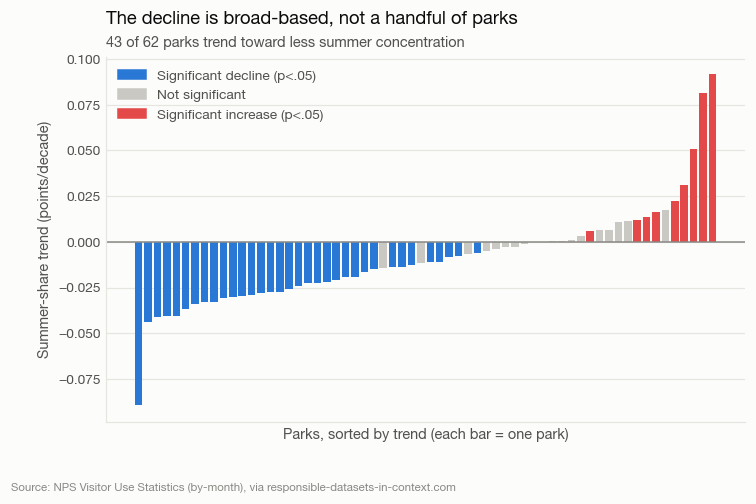

In [10]:
from matplotlib.patches import Patch

fig, ax = npviz.new_figure(7.5, 4.3)
colors = [npviz.RED if s and sl > 0 else (npviz.BLUE if s else npviz.EMPHASIS_GRAY)
          for s, sl in zip(per_park.significant, per_park.slope)]
ax.bar(range(len(per_park)), per_park.slope, color=colors, width=0.8)
ax.axhline(0, color=npviz.TEXT_MUTED, lw=1)
ax.set_xticks([])
ax.set_xlabel("Parks, sorted by trend (each bar = one park)")
ax.set_ylabel("Summer-share trend (points/decade)")
npviz.title(ax, "The decline is broad-based, not a handful of parks",
            f"{(per_park.slope < 0).sum()} of {len(per_park)} parks trend toward less summer concentration")
legend_handles = [
    Patch(color=npviz.BLUE, label="Significant decline (p<.05)"),
    Patch(color=npviz.EMPHASIS_GRAY, label="Not significant"),
    Patch(color=npviz.RED, label="Significant increase (p<.05)"),
]
ax.legend(handles=legend_handles, loc="upper left", ncol=1)
npviz.source_note(fig)
npviz.save(fig, "02_park_trend_distribution")
plt.show()


**Interpretation.** Most parks (43 of 62 with adequate history) are trending
toward *less* summer concentration, and this is the dominant, statistically
significant pattern; a minority — mostly a handful of Alaska parks
(Katmai, Wrangell–St. Elias, Lake Clark) with short seasons and growing
tourism — are trending the other way, becoming *more* summer-concentrated.
Both patterns are real and worth reporting: the national average masks
some heterogeneity, but the median park is de-seasonalizing.

## Finding 2 — Overnight camping is declining relative to visits <a id='Finding-2'></a>

**Metric.** Overnight stays (tent campers, RV campers, backcountry campers)
per 1,000 recreation visits, by year. We fit the same OLS-with-HAC trend on
the *log* of each rate, so the slope is interpretable as a percent change
per decade (appropriate since these rates can only be positive and changes
compound multiplicatively rather than linearly).

In [11]:
annual = df.groupby("Year")[["RecreationVisits", "TentCampers", "RVCampers", "Backcountry"]].sum()
per_1000 = annual[["TentCampers", "RVCampers", "Backcountry"]].div(annual["RecreationVisits"], axis=0) * 1000

camp_fits = {c: npdata.trend(per_1000[c], log=True) for c in per_1000.columns}
pd.DataFrame(camp_fits).T[["slope", "ci_low", "ci_high", "p_value", "n"]].round(2).rename(
    columns={"slope": "% change / decade", "ci_low": "CI low", "ci_high": "CI high"})


,% change / decade,CI low,CI high,p_value,n
TentCampers,-14.33,-17.12,-11.45,0.00,45.0
RVCampers,-23.95,-26.48,-21.34,0.00,45.0
Backcountry,-1.64,-5.14,1.98,0.37,45.0


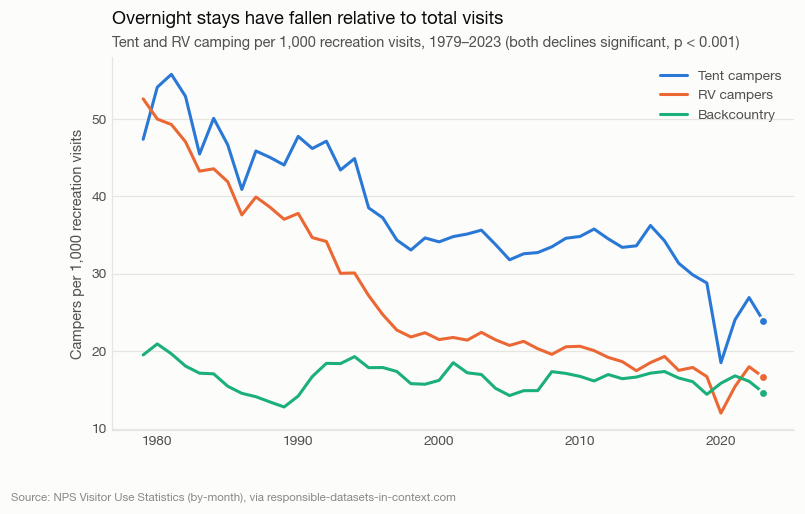

In [12]:
fig, ax = npviz.new_figure(8, 4.4)
series_colors = {"TentCampers": npviz.BLUE, "RVCampers": npviz.ORANGE, "Backcountry": npviz.AQUA}
labels = {"TentCampers": "Tent campers", "RVCampers": "RV campers", "Backcountry": "Backcountry"}
for col, color in series_colors.items():
    ax.plot(per_1000.index, per_1000[col], color=color, lw=2, label=labels[col])
    npviz.end_label(ax, per_1000.index[-1], per_1000[col].iloc[-1], "", color=color, dx=0)
ax.set_ylabel("Campers per 1,000 recreation visits")
npviz.title(ax, "Overnight stays have fallen relative to total visits",
            "Tent and RV camping per 1,000 recreation visits, 1979–2023 (both declines significant, p < 0.001)")
ax.legend(loc="upper right")
npviz.source_note(fig)
npviz.save(fig, "03_overnight_rate_trend")
plt.show()


Tent camping per 1,000 visits has fallen roughly 14% per decade and RV
camping roughly 24% per decade (both *p* < 0.001); backcountry camping shows
no significant trend. In raw counts, tent camper-nights are roughly flat and
backcountry stays have actually *grown* — it's specifically the *rate*
relative to a fast-growing visitor base that has fallen, i.e. camping
capacity/behavior hasn't kept pace with the growth in total visits.

### Is this a mix-shift, or a real behavior change?

Total visits have grown fastest in parks that were never camping-heavy
(e.g. urban-adjacent or drive-through parks). A shift-share decomposition
separates how much of the change in the *national* camping rate comes from
(a) individual parks camping less ("within"), versus (b) visit growth
shifting toward parks that camp less ("between"/mix), comparing 1979–1983
to 2017–2023 (2020–2021 are far enough from the endpoints not to be
determinative, but see the note below).

In [13]:
decomp = npdata.shift_share(df, early=(1979, 1983), late=(2017, 2023),
                            numerator=["TentCampers", "RVCampers"])
decomp.round(3)


rate_early           0.099
rate_late            0.044
total_change        -0.056
within_share         0.995
between_share       -0.233
interaction_share    0.238
within_sym           1.114
between_sym         -0.114
dtype: float64

**105.9%** of the drop is attributable to **within-park** change under a
symmetric split of the interaction term (`within_sym` above) — the same set
of parks that were high-camping in 1979 are, on average, still high-camping
in relative terms, but camping rates have fallen inside almost every park.
Visit growth shifting toward lower-camping parks (`between_sym`) actually
*offsets* the decline slightly, by −5.9%. (The raw, unsymmetrized split has
a much larger interaction term — 44.7% — which is why we report the
symmetric version: an even split of that cross-term avoids attributing a
large, hard-to-interpret residual to either side.) Either way, this rules
out the alternative explanation that national growth simply happened to
concentrate in already-low-camping parks.

We can see the same within-park pattern directly by tracking a few of the
largest, longest-running parks individually — annotated with each park's
own trend estimate, since not every park shows the decline equally:

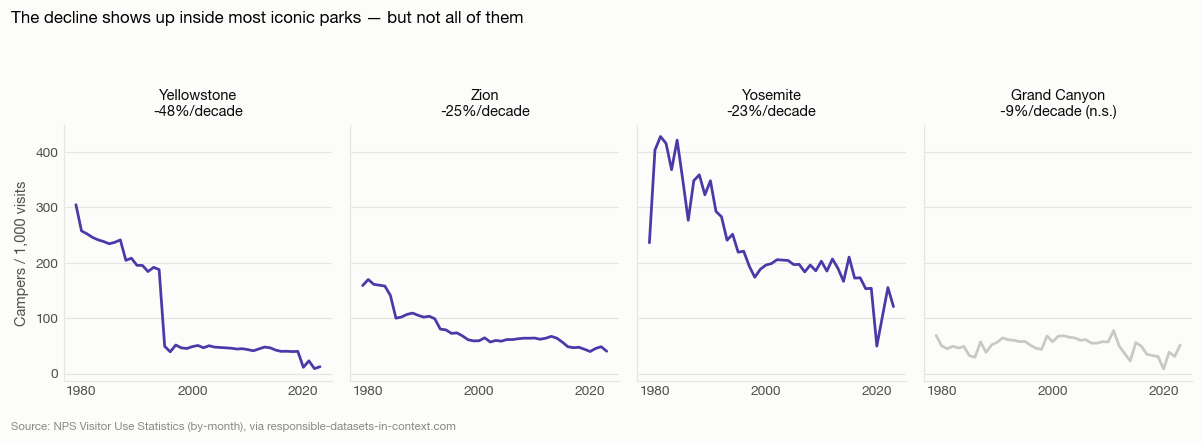

In [14]:
big_parks = ["Yellowstone NP", "Zion NP", "Yosemite NP", "Grand Canyon NP"]
fig, axes = plt.subplots(1, len(big_parks), figsize=(11, 3.4), sharey=True)
for ax, park in zip(axes, big_parks):
    sub = df[df.ParkName == park].groupby("Year")[["RecreationVisits", "TentCampers", "RVCampers"]].sum()
    rate = (sub["TentCampers"] + sub["RVCampers"]) / sub["RecreationVisits"] * 1000
    park_fit = npdata.trend(rate, log=True)
    color = npviz.VIOLET if park_fit.p_value < 0.05 else npviz.EMPHASIS_GRAY
    ax.plot(rate.index, rate.values, color=color, lw=1.8)
    star = "" if park_fit.p_value < 0.05 else " (n.s.)"
    ax.set_title(f"{park.replace(' NP', '')}\n{park_fit.slope:+.0f}%/decade{star}",
                 fontsize=9.5, color=npviz.TEXT_PRIMARY, loc="center")
    ax.set_xticks([1980, 2000, 2020])
    ax.grid(axis="y", color=npviz.GRID, lw=0.8)
axes[0].set_ylabel("Campers / 1,000 visits")
fig.suptitle("The decline shows up inside most iconic parks — but not all of them",
             fontsize=11, fontweight="bold", x=0.01, ha="left", y=1.08)
npviz.source_note(fig)
npviz.save(fig, "04_within_park_camping")
plt.tight_layout()
plt.show()


## Supporting context <a id='Supporting-context'></a>

Two additional patterns are useful context for the two findings above, but
are not standalone claims: a park-level seasonal typology (helps explain
*why* the national trend isn't universal — see Finding 1's robustness
section), and the 2020 shock (a single event, so treated as texture and a
data-quality note rather than a generalizable trend).

### Every park has its own peak season

In [15]:
recent = df[df.Year.between(2019, 2023)]
park_month = npdata.monthly_matrix(recent, ["ParkName"])
park_month_norm = park_month.div(park_month.sum(axis=1), axis=0)
peak_month = park_month_norm.idxmax(axis=1)
order = peak_month.sort_values(kind="stable").index
mat = park_month_norm.loc[order]

n = len(mat)
desert_n = int((peak_month.loc[order] <= 4).sum())
alpine_n = int((peak_month.loc[order] >= 8).sum())
print(f"{desert_n} winter/spring-peak parks, {alpine_n} summer-peak parks, "
      f"{n - desert_n - alpine_n} peak in the Jul/Aug core")


10 winter/spring-peak parks, 14 summer-peak parks, 39 peak in the Jul/Aug core


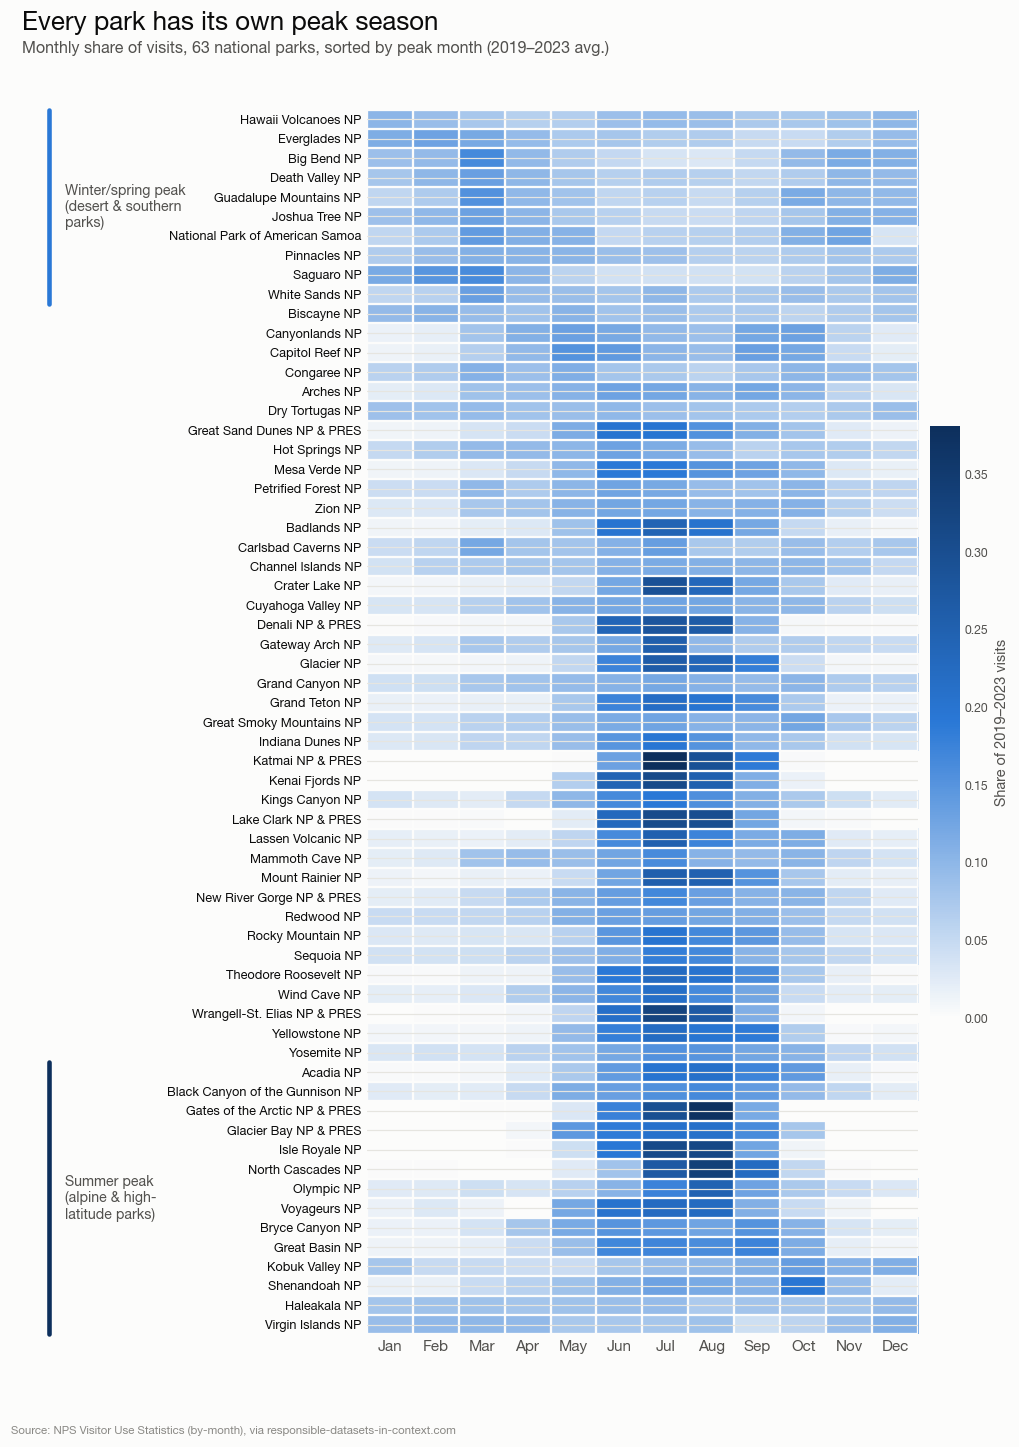

In [16]:
import matplotlib.lines as mlines

fig = plt.figure(figsize=(9.8, 12.8))
fig.patch.set_facecolor(npviz.SURFACE)
ax = fig.add_axes([0.34, 0.045, 0.55, 0.87])
ax.set_facecolor(npviz.SURFACE)

im = ax.imshow(mat.values, aspect="auto", cmap=npviz.SEQUENTIAL, vmin=0, vmax=mat.values.max())
ax.set_xticks(range(12))
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"],
                    fontsize=10, color=npviz.TEXT_SECONDARY)
ax.set_yticks(range(n))
ax.set_yticklabels(mat.index, fontsize=8.3, color=npviz.TEXT_PRIMARY)
ax.tick_params(length=0)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xticks(np.arange(-0.5, 12, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n, 1), minor=True)
ax.grid(which="minor", color=npviz.SURFACE, linewidth=1.5)
ax.tick_params(which="minor", length=0)

cbar = fig.colorbar(im, ax=ax, fraction=0.05, pad=0.02)
cbar.set_label("Share of 2019–2023 visits", fontsize=9.5, color=npviz.TEXT_SECONDARY)
cbar.ax.tick_params(labelsize=8, labelcolor=npviz.TEXT_SECONDARY)
cbar.outline.set_visible(False)

def row_to_fig_y(row):
    disp = ax.transData.transform((0, row))
    return fig.transFigure.inverted().transform(disp)[1]

top_y, desert_bottom_y = row_to_fig_y(-0.5), row_to_fig_y(desert_n - 0.5)
alpine_top_y, bottom_y = row_to_fig_y(n - alpine_n - 0.5), row_to_fig_y(n - 0.5)
bracket_x = 0.045
fig.add_artist(mlines.Line2D([bracket_x, bracket_x], [desert_bottom_y, top_y], color=npviz.BLUE,
                              lw=3, solid_capstyle="round", transform=fig.transFigure))
fig.text(bracket_x + 0.015, (top_y + desert_bottom_y) / 2, "Winter/spring peak\n(desert & southern\nparks)",
          fontsize=9.3, color=npviz.TEXT_SECONDARY, ha="left", va="center")
fig.add_artist(mlines.Line2D([bracket_x, bracket_x], [bottom_y, alpine_top_y], color=npviz.DARK_BLUE,
                              lw=3, solid_capstyle="round", transform=fig.transFigure))
fig.text(bracket_x + 0.015, (alpine_top_y + bottom_y) / 2, "Summer peak\n(alpine & high-\nlatitude parks)",
          fontsize=9.3, color=npviz.TEXT_SECONDARY, ha="left", va="center")

fig.suptitle("Every park has its own peak season", fontsize=17, fontweight="bold",
             color=npviz.TEXT_PRIMARY, x=0.02, ha="left", y=0.985)
fig.text(0.02, 0.955, "Monthly share of visits, 63 national parks, sorted by peak month (2019–2023 avg.)",
          fontsize=10.5, color=npviz.TEXT_SECONDARY, ha="left")
npviz.source_note(fig)
npviz.save(fig, "05_seasonal_typology_heatmap")
plt.show()


This explains why Finding 1's per-park trend chart has a small cluster of
increasing parks: they are disproportionately the extreme summer-peak
Alaska parks (Katmai, Wrangell–St. Elias, Lake Clark), which have historically
had very short, hard seasons and are seeing that season lengthen slightly as
tourism to them grows — the opposite direction from the desert-park pattern
but consistent with the same broader story of *changing* seasonal windows.

### The 2020 shock hit regions unevenly

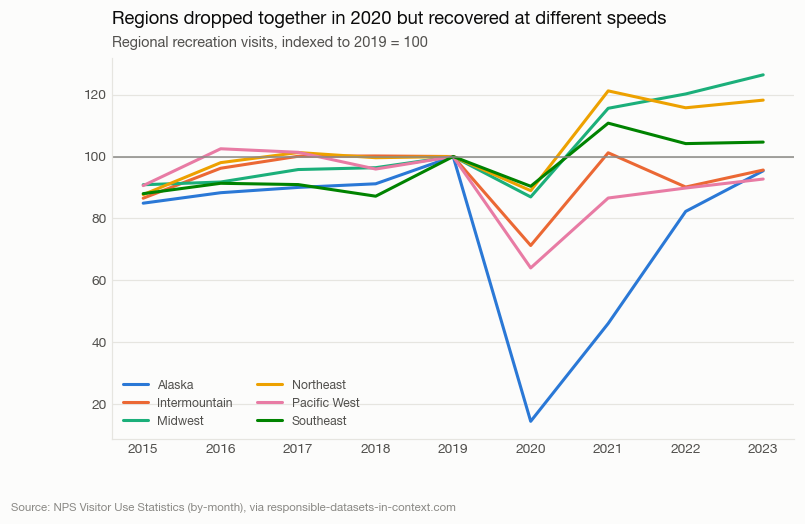

In [17]:
region_year = df.groupby(["Region", "Year"])["RecreationVisits"].sum().unstack("Year")
region_idx = region_year.div(region_year[2019], axis=0) * 100

fig, ax = npviz.new_figure(8, 4.5)
for color, region in zip(npviz.CATEGORICAL, region_idx.index):
    sub = region_idx.loc[region, 2015:2023]
    ax.plot(sub.index, sub.values, lw=2, color=color, label=region)
ax.axhline(100, color=npviz.TEXT_MUTED, lw=1, ls=(0, (1, 0)))
npviz.title(ax, "Regions dropped together in 2020 but recovered at different speeds",
            "Regional recreation visits, indexed to 2019 = 100")
ax.legend(loc="lower left", fontsize=8, ncol=2)
npviz.source_note(fig)
npviz.save(fig, "06_regional_covid_recovery")
plt.show()


**Data-quality note.** The data essay flags known counter outages (e.g.
Carlsbad Caverns' counter broken since 2019) and non-reporting zeros (e.g.
Kobuk Valley, 2014–2015), and that the 2024 annual figures were reportedly
suppressed after release. We restrict this analysis to 2023 and earlier for
that reason. Checking whether the 2020 regional drop is inflated by
non-reporting rather than real closures:

In [18]:
zeros_2020 = df[(df.Year == 2020) & (df.ZeroMonth)]
print(f"{len(zeros_2020)} zero-visit rows in 2020 across {zeros_2020.ParkName.nunique()} parks — "
      f"a small share of the {df[df.Year==2020].shape[0]} park-months that year, "
      "consistent with real (COVID) closures rather than a reporting artifact.")


46 zero-visit rows in 2020 across 26 parks — a small share of the 756 park-months that year, consistent with real (COVID) closures rather than a reporting artifact.


## Limitations and generalizability <a id='Limitations'></a>

- **Measurement, not census.** "Recreation visits" are estimated from
  traffic counters and manual counts, adjusted by park-specific formulas
  that changed over 45 years (per the data essay). A slow methodological
  drift toward more granular counting could itself produce part of a
  "de-seasonalization" signal if peak-month counts were historically
  cruder than shoulder-month counts — we have no way to rule this out from
  the visitation data alone, so we treat the finding as measured-share
  de-seasonalization, not a claim about literal foot traffic.
- **Definitional exclusions.** The data essay notes that "recreation
  visits" exclude commuters, researchers, staff, and Indigenous residents
  of park lands, and that limited accessibility means visitors are not
  representative of the U.S. population. Our findings describe *counted*
  visitation behavior, not visitation in the broadest social sense.
- **Camping rate is a behavior proxy, not a survey.** `TentCampers` /
  `RVCampers` reflect campground *stays*, which are also bounded by fixed
  campsite capacity in popular parks — a flat or declining rate could
  partly reflect a capacity ceiling rather than pure declining demand for
  camping. We cannot separate supply constraints from demand shifts with
  this dataset alone.
- **One shock event.** The 2020 regional-recovery pattern (Supporting
  context) is a single case (one pandemic), not a repeated, generalizable
  pattern — we present it as texture, not as a claim in its own right.
- **Generalizability.** The 45-year, near-universal-panel trends (Findings
  1 and 2) are our strongest basis for expecting the *direction* of these
  patterns to continue into future years, though the *rate* of decline is
  unlikely to be constant (both slow markedly after ~2010 in the raw
  series). We would not extend either finding to park types not
  represented in this list (63 "National Park"-designated units only —
  national monuments, seashores, and historic sites are excluded from this
  file and may behave differently).


## Assignment response <a id='Assignment-response'></a>

This section answers the mini-project prompts directly, in order, drawing on
the analysis above in [Finding 1](#Finding-1), [Finding 2](#Finding-2),
[Supporting context](#Supporting-context) and [Limitations](#Limitations),
and adding further analysis of its own where the prompts call for depth the
earlier sections do not reach.

### Claim

Americans have not stopped visiting national parks in summer — they have
added visits everywhere else. Between 1979 and 2023 the June–August share of
visits fell about 1.6 percentage points per decade even though summer
visitation itself *grew* 29%, while front-country overnight stays fell from
about 118 to 60 per 1,000 visits, so the typical park visit has steadily
become a shoulder-season day trip rather than a summer camping trip.

### Analysis supporting the claim

Both halves of the claim are trend estimates rather than before/after
comparisons, because a single pair of endpoints (e.g. "1979 vs. 2023") would
be sensitive to whatever those two particular years happened to look like.
For each year we compute (a) the national share of recreation visits falling
in June–August and (b) campers per 1,000 recreation visits, then fit an
ordinary-least-squares trend of each measure on year with Newey–West (HAC)
standard errors, which allow for the serial correlation that adjacent years
of the same series obviously have (`npdata.trend`). Camping rates are
modelled in logs so the slope reads as a percent change per decade, which
suits a strictly positive rate that changes multiplicatively.

The first figure puts both fitted trends side by side, reusing the exact
series and fits computed in Finding 1 (`summer`, `fit`) and Finding 2
(`per_1000`, `camp_fits`) rather than recomputing anything:

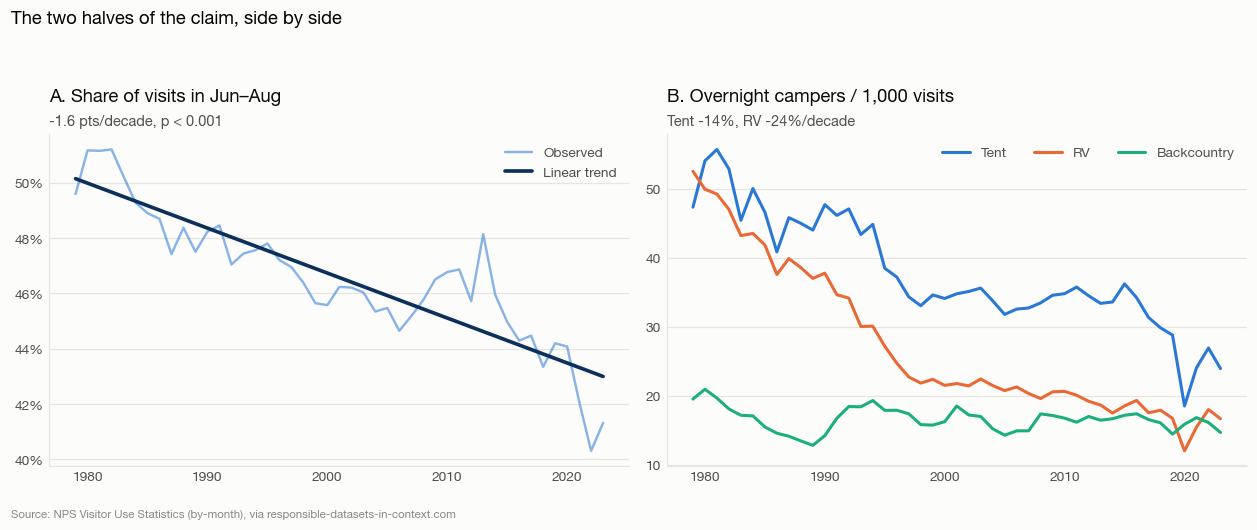

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))

# Panel A: national summer-visit share and its trend (Finding 1)
ax = axes[0]
ax.plot(summer.index, summer.values, color=npviz.BLUE, lw=1.6, alpha=0.55, label="Observed")
ax.plot(years, pred, color=npviz.DARK_BLUE, lw=2.4, label="Linear trend")
npviz.pct_axis(ax)
npviz.title(ax, "A. Share of visits in Jun–Aug",
            f"{fit.slope * 100:+.1f} pts/decade, p < 0.001")
ax.legend(loc="upper right")

# Panel B: overnight-camping rate and its trend (Finding 2)
ax = axes[1]
series_colors = {"TentCampers": npviz.BLUE, "RVCampers": npviz.ORANGE, "Backcountry": npviz.AQUA}
labels = {"TentCampers": "Tent", "RVCampers": "RV", "Backcountry": "Backcountry"}
for col, color in series_colors.items():
    ax.plot(per_1000.index, per_1000[col], color=color, lw=2, label=labels[col])
npviz.title(ax, "B. Overnight campers / 1,000 visits",
            f"Tent {camp_fits['TentCampers'].slope:+.0f}%, "
            f"RV {camp_fits['RVCampers'].slope:+.0f}%/decade")
ax.legend(loc="upper right", ncols=3)

fig.suptitle("The two halves of the claim, side by side",
             fontsize=12, fontweight="bold", x=0.01, ha="left", y=1.06)
npviz.source_note(fig)
npviz.save(fig, "07_claim_summary_panels")
plt.tight_layout()
plt.show()


Panel A establishes that the summer share is falling and Panel B that the
camping rate is falling faster still. Neither panel, on its own, says *what
moved* — and that turns out to matter for how the claim should be worded.
The next three steps take each half of the claim apart.

**Which months actually changed?** "Summer share fell" is a statement about
one three-month block. Fitting the same trend to all twelve months
separately shows where the share went instead, and whether the movement is
concentrated or spread:

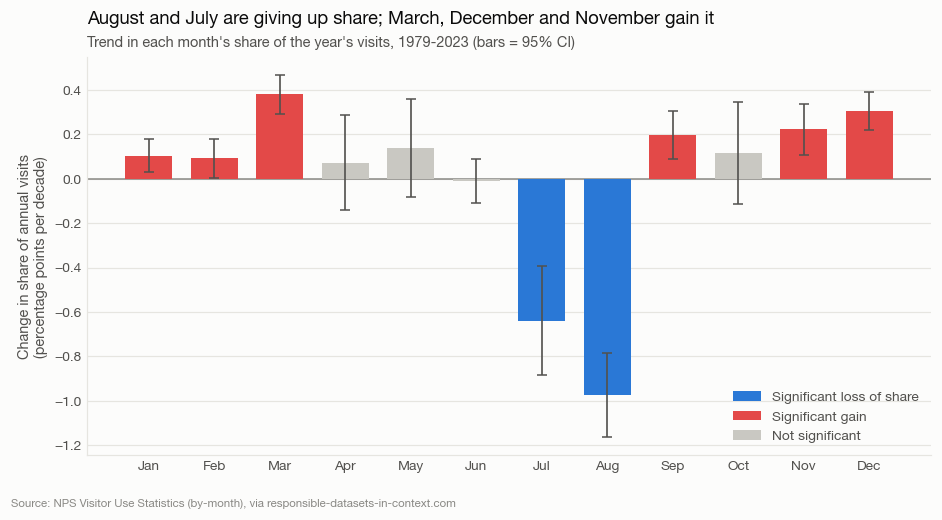

,slope,ci_low,ci_high,p_value
Jan,0.105,0.030,0.179,0.006
Feb,0.091,0.004,0.179,0.040
Mar,0.380,0.293,0.466,0.000
Apr,0.073,-0.141,0.287,0.506
May,0.137,-0.083,0.357,0.222
Jun,-0.012,-0.110,0.087,0.819
Jul,-0.639,-0.885,-0.392,0.000
Aug,-0.975,-1.164,-0.786,0.000
Sep,0.196,0.087,0.304,0.000
Oct,0.116,-0.114,0.346,0.325


In [20]:
from matplotlib.patches import Patch

month_share = national_matrix.div(national_matrix.sum(axis=1), axis=0)
month_fits = pd.DataFrame({m: npdata.trend(month_share[m]) for m in range(1, 13)}).T
for col in ["slope", "ci_low", "ci_high"]:
    month_fits[col] *= 100          # fractions -> percentage points
month_fits["significant"] = month_fits.p_value < 0.05

MONTHS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
fig, ax = npviz.new_figure(8.6, 4.5)
bar_colors = [npviz.RED if (s and v > 0) else (npviz.BLUE if s else npviz.EMPHASIS_GRAY)
              for s, v in zip(month_fits.significant, month_fits.slope)]
ax.bar(range(12), month_fits.slope, color=bar_colors, width=0.72, zorder=3)
ax.errorbar(range(12), month_fits.slope,
            yerr=[month_fits.slope - month_fits.ci_low, month_fits.ci_high - month_fits.slope],
            fmt="none", ecolor=npviz.TEXT_SECONDARY, elinewidth=1.1, capsize=3, zorder=4)
ax.axhline(0, color=npviz.TEXT_MUTED, lw=1, zorder=2)
ax.set_xticks(range(12))
ax.set_xticklabels(MONTHS)
ax.set_ylabel("Change in share of annual visits\n(percentage points per decade)")
ax.legend(handles=[Patch(facecolor=npviz.BLUE, label="Significant loss of share"),
                   Patch(facecolor=npviz.RED, label="Significant gain"),
                   Patch(facecolor=npviz.EMPHASIS_GRAY, label="Not significant")],
          loc="lower right")
npviz.title(ax, "August and July are giving up share; March, December and November gain it",
            "Trend in each month's share of the year's visits, 1979-2023 (bars = 95% CI)")
npviz.source_note(fig)
npviz.save(fig, "10_month_share_trends")
plt.tight_layout()
plt.show()

month_fits[["slope", "ci_low", "ci_high", "p_value"]].set_axis(MONTHS).round(3)


This is more specific than "summer is declining." The losses are
concentrated in the two deep-summer months — August (−0.98 points/decade)
and July (−0.64) — while June is flat and statistically indistinguishable
from no change. The offsetting gains are spread thinly across the cold and
shoulder months, and the single biggest winner is **March** (+0.38
points/decade), ahead of December (+0.30), November (+0.22) and September
(+0.20). By construction the twelve slopes sum to zero, so this is a
redistribution of a fixed 100%, not growth or decline in itself.

That March leads is a useful corrective to the intuitive story. A pure
"climate lengthens the hiking season" account would predict the gains
landing symmetrically in May/June and September/October; instead the largest
gain sits in early spring, which is when desert parks peak and when school
spring break falls — a pattern much more consistent with *which parks and
trips people choose* than with warmer shoulder weather alone.

**Is summer actually shrinking?** A falling share is compatible with two
very different worlds: summer visitation declining, or summer growing more
slowly than everything else. These have opposite implications for crowding
and staffing, so the distinction matters. Comparing absolute visit counts
separates them:

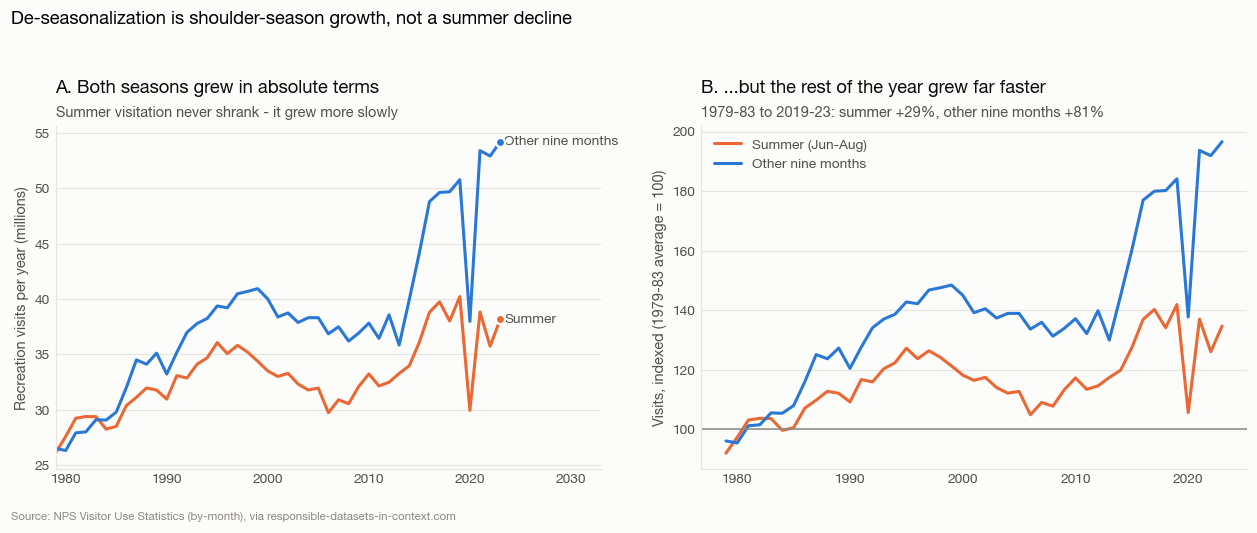

In [21]:
is_summer = df.Month.isin(npdata.SUMMER)
abs_year = pd.DataFrame({
    "Summer (Jun-Aug)": df[is_summer].groupby("Year").RecreationVisits.sum(),
    "Other nine months": df[~is_summer].groupby("Year").RecreationVisits.sum()})
growth = (abs_year.loc[2019:2023].mean() / abs_year.loc[1979:1983].mean() - 1) * 100
indexed = abs_year.div(abs_year.loc[1979:1983].mean()) * 100

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3))
ax = axes[0]
for col, color in zip(abs_year.columns, [npviz.ORANGE, npviz.BLUE]):
    ax.plot(abs_year.index, abs_year[col] / 1e6, color=color, lw=2)
    npviz.end_label(ax, abs_year.index[-1], abs_year[col].iloc[-1] / 1e6, col.split(" (")[0], color=color)
ax.set_xlim(1979, 2033)
ax.set_ylabel("Recreation visits per year (millions)")
npviz.title(ax, "A. Both seasons grew in absolute terms",
            "Summer visitation never shrank - it grew more slowly")

ax = axes[1]
for col, color in zip(indexed.columns, [npviz.ORANGE, npviz.BLUE]):
    ax.plot(indexed.index, indexed[col], color=color, lw=2, label=col)
ax.axhline(100, color=npviz.TEXT_MUTED, lw=1)
ax.set_ylabel("Visits, indexed (1979-83 average = 100)")
ax.legend(loc="upper left")
npviz.title(ax, "B. ...but the rest of the year grew far faster",
            f"1979-83 to 2019-23: summer {growth.iloc[0]:+.0f}%, other nine months {growth.iloc[1]:+.0f}%")

fig.suptitle("De-seasonalization is shoulder-season growth, not a summer decline",
             fontsize=12, fontweight="bold", x=0.01, ha="left", y=1.04)
npviz.source_note(fig)
npviz.save(fig, "11_absolute_season_growth")
plt.tight_layout()
plt.show()


Summer visitation grew 29% between the first and last five years of the
panel; the other nine months grew 81%, nearly three times faster. So the
falling summer share reflects the rest of the calendar filling in, not
summer emptying out — the claim is about *redistribution*, and any wording
implying parks are quieter in August than they used to be would be wrong.
In absolute terms August is busier than ever; it simply no longer dominates
the year the way it did.

**Is the camping decline just a denominator effect?** A rate can fall
because its numerator shrinks or because its denominator grows. Since total
visits rose 55% over the same period, a falling camping *rate* could in
principle coexist with rising camping. Plotting the numerator directly
settles it:

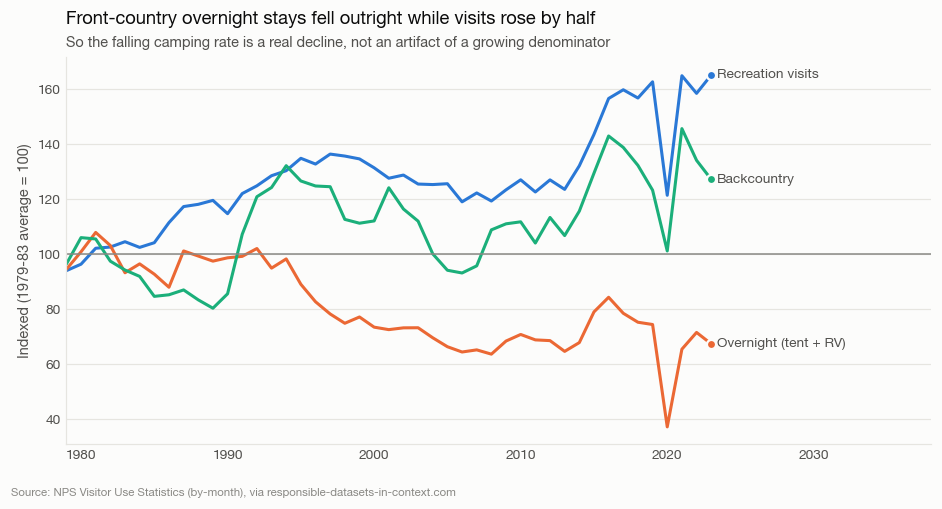

,"% change, 1979-83 to 2019-23"
Recreation visits,54.6
Overnight (tent + RV),-36.7
Backcountry,26.4


In [22]:
annual_tot = df.groupby("Year")[["RecreationVisits", "TentCampers", "RVCampers", "Backcountry"]].sum()
annual_tot["Overnight (tent + RV)"] = annual_tot.TentCampers + annual_tot.RVCampers
absolute = annual_tot[["RecreationVisits", "Overnight (tent + RV)", "Backcountry"]].rename(
    columns={"RecreationVisits": "Recreation visits"})
abs_change = (absolute.loc[2019:2023].mean() / absolute.loc[1979:1983].mean() - 1) * 100
abs_indexed = absolute.div(absolute.loc[1979:1983].mean()) * 100

fig, ax = npviz.new_figure(8.6, 4.4)
for col, color in zip(abs_indexed.columns, [npviz.BLUE, npviz.ORANGE, npviz.AQUA]):
    ax.plot(abs_indexed.index, abs_indexed[col], color=color, lw=2)
    npviz.end_label(ax, abs_indexed.index[-1], abs_indexed[col].iloc[-1], col, color=color)
ax.axhline(100, color=npviz.TEXT_MUTED, lw=1)
ax.set_xlim(1979, 2038)
ax.set_ylabel("Indexed (1979-83 average = 100)")
npviz.title(ax, "Front-country overnight stays fell outright while visits rose by half",
            "So the falling camping rate is a real decline, not an artifact of a growing denominator")
npviz.source_note(fig)
npviz.save(fig, "12_absolute_overnight")
plt.tight_layout()
plt.show()

abs_change.round(1).rename("% change, 1979-83 to 2019-23").to_frame()


Front-country overnight stays fell 37% in absolute terms while recreation
visits rose 55% — so the falling rate is driven by the numerator, and the
denominator effect works *against* the finding rather than creating it.
Backcountry stays are the exception: they rose 26% absolutely, which is
roughly in line with a growing visitor base and is why the backcountry rate
shows no significant trend. The decline is specific to developed
campgrounds, not to sleeping outdoors in general.

**A formal within-park test.** Finding 2's shift-share decomposition
attributes the aggregate move to within-park change, but it compares two
period averages and says nothing about the years between. A panel
regression with park fixed effects is the stronger version of the same test:
every time-invariant difference between parks (size, climate, road access,
whether it has campgrounds at all) is absorbed, so the year coefficient is
identified purely from change *inside* parks over time, with standard errors
clustered by park (`npdata.panel_trend`):

In [23]:
# Summer share: within-park trend (fractions -> percentage points)
fe_season = npdata.panel_trend(park_share)

# Camping rate per park-year: within-park trend on the log rate (-> % per decade)
park_year = df.groupby(["ParkName", "Year"])[["RecreationVisits", "TentCampers", "RVCampers"]].sum()
park_year = park_year[park_year.RecreationVisits > 0]
camp_rate_py = ((park_year.TentCampers + park_year.RVCampers) / park_year.RecreationVisits * 1000)
camp_rate_py = camp_rate_py.replace(0, np.nan).dropna()
fe_camp = npdata.panel_trend(camp_rate_py, log=True)

fe_table = pd.DataFrame(
    {"estimate": [fe_season.slope * 100, fe_camp.slope],
     "ci_low": [fe_season.ci_low * 100, fe_camp.ci_low],
     "ci_high": [fe_season.ci_high * 100, fe_camp.ci_high],
     "p_value": [fe_season.p_value, fe_camp.p_value],
     "park_years": [fe_season.n_obs, fe_camp.n_obs],
     "parks": [fe_season.n_units, fe_camp.n_units]},
    index=["Summer share (pp/decade)", "Camping rate (%/decade)"])
fe_table.round(3)


,estimate,ci_low,ci_high,p_value,park_years,parks
Summer share (pp/decade),-0.925,-1.584,-0.266,0.006,2779.0,63.0
Camping rate (%/decade),-18.950,-25.110,-12.285,0.000,2036.0,51.0


Both findings survive the stricter test. Within the average park the
summer share falls 0.93 points per decade (95% CI −1.58 to −0.27,
*p* = 0.006, 2,779 park-years) and the camping rate falls 19.0% per decade
(95% CI −25.1 to −12.3, *p* < 0.001, 2,036 park-years across the 51 parks
that record any camping). Neither finding is an artifact of *which* parks
people visit.

Two details are worth flagging honestly. First, the within-park summer-share
estimate (−0.93) is noticeably smaller than the national visit-weighted one
(−1.62), and close to the unweighted park average — meaning the aggregate
number is amplified by the largest parks de-seasonalizing faster than the
typical park. Both are true; the national figure describes the visiting
public's experience, the within-park figure describes the average park, and
the claim above quotes the national one. Second, the camping panel drops 12
parks with no recorded camping, so that estimate speaks to parks that have
campgrounds rather than to the system as a whole.

### Elaboration

A claim earns confidence by surviving reasonable changes to how it is
measured, and by varying across time and place in ways that make sense
rather than arbitrarily. This section works through four questions in turn:
whether the specification drives the result, whether it holds everywhere,
whether the two halves of the claim are really one phenomenon, and whether
the pace has been constant.

**1. Does the specification drive the result?** Finding 1's robustness
table refits the summer-share trend four ways — visit-weighted nationally,
as an unweighted mean across parks, excluding the COVID-affected 2020–2021
years, and using each park's own best three consecutive months instead of a
fixed calendar summer. Two more are added here: the within-park
fixed-effects estimate from the section above, and a balanced panel that
keeps only the 55 parks observed across the entire window, since 8 parks
enter the file late and could otherwise change the national mix over
time.

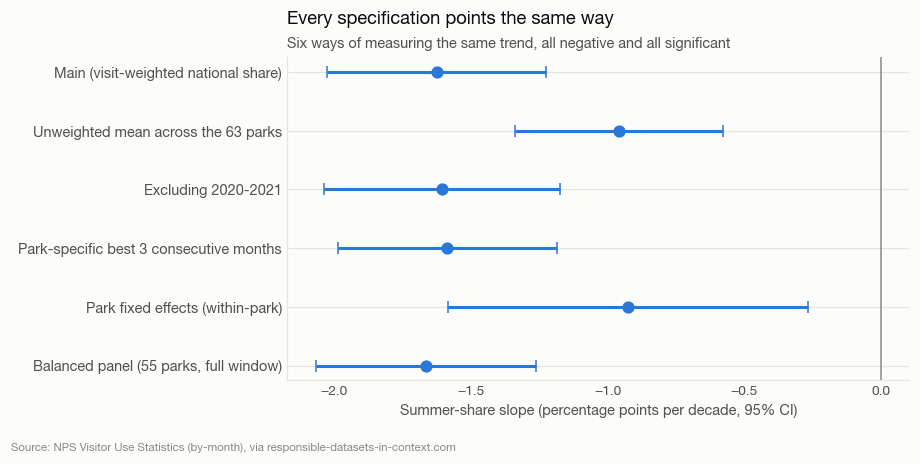

,slope,ci_low,ci_high,p_value
Main (visit-weighted national share),-1.625,-2.024,-1.226,0.000
Unweighted mean across the 63 parks,-0.958,-1.338,-0.578,0.000
Excluding 2020-2021,-1.605,-2.036,-1.174,0.000
Park-specific best 3 consecutive months,-1.586,-1.988,-1.185,0.000
Park fixed effects (within-park),-0.925,-1.584,-0.266,0.006
"Balanced panel (55 parks, full window)",-1.664,-2.068,-1.260,0.000


In [24]:
specs = dict(checks)          # the four specifications fitted under Finding 1

# (e) within-park estimate from the fixed-effects panel above
specs["Park fixed effects (within-park)"] = fe_season

# (f) balanced panel: only parks observed across the whole 1979-2023 window,
#     since 8 parks enter the file late (Alaska parks 1982, Congaree 1985,
#     American Samoa 2002) and could otherwise shift the national mix over time
span = df.groupby("ParkName").Year.agg(["min", "max"])
balanced_parks = span[(span["min"] <= 1979) & (span["max"] >= 2023)].index
specs[f"Balanced panel ({len(balanced_parks)} parks, full window)"] = npdata.trend(
    npdata.summer_share(npdata.monthly_matrix(df[df.ParkName.isin(balanced_parks)], ["Year"])))

fig, ax = npviz.new_figure(8.4, 4.0)
names = list(specs.keys())
est = [specs[k].slope * 100 for k in names]
lo = [(specs[k].slope - specs[k].ci_low) * 100 for k in names]
hi = [(specs[k].ci_high - specs[k].slope) * 100 for k in names]

ax.errorbar(est, range(len(names)), xerr=[lo, hi], fmt="o", color=npviz.BLUE,
            ecolor=npviz.BLUE, elinewidth=2, capsize=4, markersize=7, zorder=3)
ax.axvline(0, color=npviz.TEXT_MUTED, lw=1, zorder=1)
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=9.5)
ax.invert_yaxis()
ax.set_xlabel("Summer-share slope (percentage points per decade, 95% CI)")
npviz.title(ax, "Every specification points the same way",
            "Six ways of measuring the same trend, all negative and all significant")
npviz.source_note(fig)
npviz.save(fig, "08_robustness_forest_plot")
plt.tight_layout()
plt.show()

pd.DataFrame({k: specs[k][["slope", "ci_low", "ci_high", "p_value"]] * [100, 100, 100, 1]
              for k in names}).T.round(3)


All six intervals sit entirely below zero. The estimates fall into two
groups that differ for an interpretable reason rather than a worrying one:
the three visit-weighted national specifications cluster near −1.6
points/decade, while the two that give every park equal weight (the
unweighted mean and the fixed-effects panel) sit nearer −0.9, because the
largest parks are de-seasonalizing faster than the median park. The
balanced panel (−1.66) is indistinguishable from the full panel (−1.62),
so the late-entering parks — 1.8% of all recorded visits — are not driving
anything.

**2. Does it hold everywhere?** The national figure could mask a pattern
driven by one part of the country. Fitting the same trend within each NPS
region tests that directly:

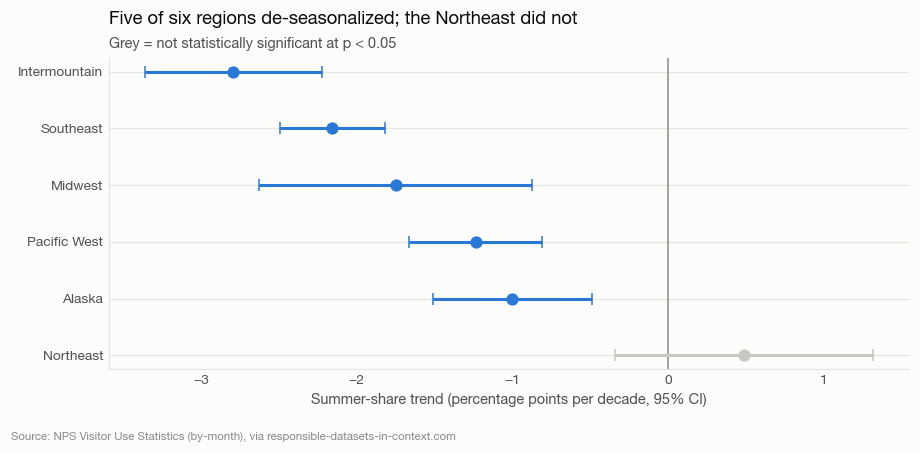

,slope,ci_low,ci_high,p_value
Intermountain,-2.792,-3.359,-2.225,0.000
Southeast,-2.156,-2.494,-1.818,0.000
Midwest,-1.749,-2.627,-0.871,0.000
Pacific West,-1.236,-1.664,-0.809,0.000
Alaska,-1.000,-1.512,-0.488,0.000
Northeast,0.487,-0.342,1.316,0.249


In [25]:
region_share = npdata.summer_share(npdata.monthly_matrix(df, ["Region", "Year"])).dropna()
region_fits = pd.DataFrame({r: npdata.trend(s.droplevel(0))
                            for r, s in region_share.groupby(level=0)}).T
for col in ["slope", "ci_low", "ci_high"]:
    region_fits[col] *= 100
region_fits = region_fits.sort_values("slope")

fig, ax = npviz.new_figure(8.4, 3.9)
region_colors = [npviz.BLUE if p < 0.05 else npviz.EMPHASIS_GRAY for p in region_fits.p_value]
for i, (row, color) in enumerate(zip(region_fits.itertuples(), region_colors)):
    ax.errorbar(row.slope, i, xerr=[[row.slope - row.ci_low], [row.ci_high - row.slope]],
                fmt="o", color=color, ecolor=color, elinewidth=2, capsize=4, markersize=7, zorder=3)
ax.axvline(0, color=npviz.TEXT_MUTED, lw=1)
ax.set_yticks(range(len(region_fits)))
ax.set_yticklabels(region_fits.index)
ax.invert_yaxis()
ax.set_xlabel("Summer-share trend (percentage points per decade, 95% CI)")
npviz.title(ax, "Five of six regions de-seasonalized; the Northeast did not",
            "Grey = not statistically significant at p < 0.05")
npviz.source_note(fig)
npviz.save(fig, "13_regional_trends")
plt.tight_layout()
plt.show()

region_fits[["slope", "ci_low", "ci_high", "p_value"]].round(3)


Five of six regions de-seasonalized significantly, but the size of the
effect varies more than threefold — from −2.79 points/decade in the
Intermountain region (the Utah/Colorado desert and canyon parks) down to
−1.00 in Alaska. The **Northeast is the exception**: its estimate is
slightly *positive* (+0.49) and not significant, so we cannot say it
de-seasonalized at all.

That ordering is informative rather than random. The regions with the most
room to spread visits into a mild off-season moved most, while the Northeast
— where winter genuinely closes much of the visitor infrastructure and
Acadia's season is weather-bound — barely moved. This is a real limit on the
claim's scope: it describes national and especially Western visitation, not
every park system equally.

**3. Are the two halves of the claim one phenomenon or two?** The claim
bundles de-seasonalization and declining overnight stays into a single
sentence about shorter, off-peak trips. If they were one underlying shift,
parks that de-seasonalized most should also have shed camping fastest. It is
worth testing that rather than assuming it — along with a second check, that
the trend is not simply a ceiling effect in which the parks that started
most summer-concentrated had the most room to fall:

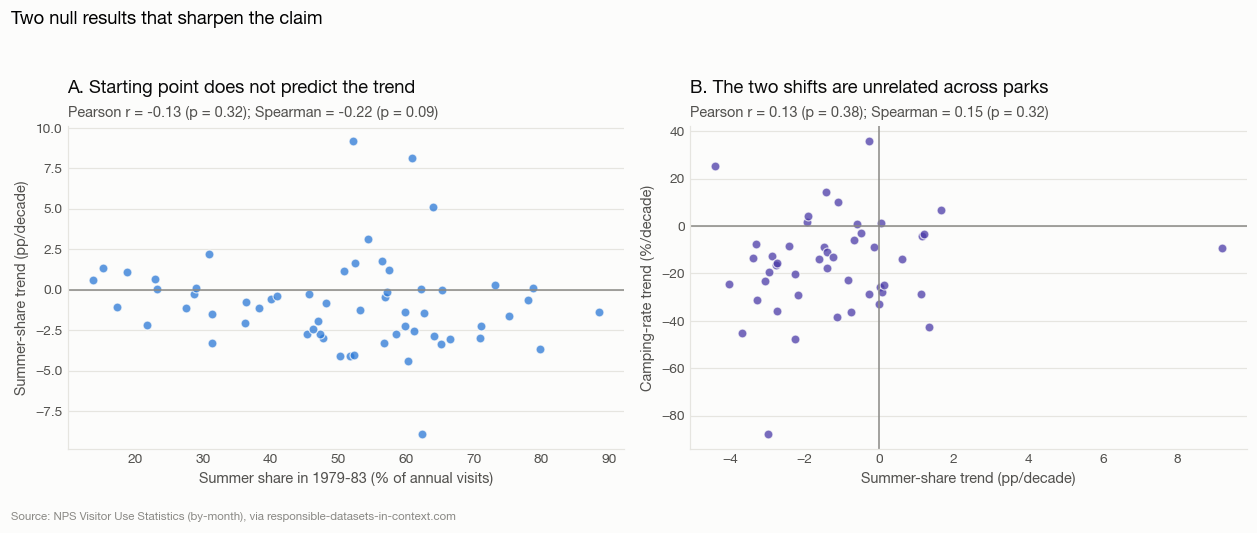

n = 60 parks (panel A), 47 parks (panel B)


In [26]:
from scipy import stats

# (a) does a park's starting summer share predict how fast it de-seasonalized?
baseline = (park_share[park_share.index.get_level_values("Year").isin(range(1979, 1984))]
            .groupby(level=0).mean())
base_vs_trend = per_park.join(baseline.rename("baseline")).dropna(subset=["baseline"])
r_base, p_base = stats.pearsonr(base_vs_trend.baseline * 100, base_vs_trend.slope * 100)
rho_base, prho_base = stats.spearmanr(base_vs_trend.baseline, base_vs_trend.slope)

# (b) do parks that de-seasonalized also lose camping fastest?
camp_park_trends = {}
for park, s in camp_rate_py.groupby(level=0):
    s = s.droplevel(0).dropna()
    if len(s) >= 20:
        camp_park_trends[park] = npdata.trend(s, log=True)
camp_park_trends = pd.DataFrame(camp_park_trends).T

paired = (per_park[["slope"]].rename(columns={"slope": "season_trend"})
          .join(camp_park_trends[["slope"]].rename(columns={"slope": "camp_trend"}), how="inner")
          .dropna())
paired["season_trend"] *= 100
r_pair, p_pair = stats.pearsonr(paired.season_trend, paired.camp_trend)
rho_pair, prho_pair = stats.spearmanr(paired.season_trend, paired.camp_trend)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3))
ax = axes[0]
ax.scatter(base_vs_trend.baseline * 100, base_vs_trend.slope * 100, color=npviz.BLUE,
           s=34, alpha=0.75, edgecolor=npviz.SURFACE, linewidth=0.8)
ax.axhline(0, color=npviz.TEXT_MUTED, lw=1)
ax.set_xlabel("Summer share in 1979-83 (% of annual visits)")
ax.set_ylabel("Summer-share trend (pp/decade)")
npviz.title(ax, "A. Starting point does not predict the trend",
            f"Pearson r = {r_base:.2f} (p = {p_base:.2f}); Spearman = {rho_base:.2f} (p = {prho_base:.2f})")

ax = axes[1]
ax.scatter(paired.season_trend, paired.camp_trend, color=npviz.VIOLET,
           s=34, alpha=0.75, edgecolor=npviz.SURFACE, linewidth=0.8)
ax.axhline(0, color=npviz.TEXT_MUTED, lw=1)
ax.axvline(0, color=npviz.TEXT_MUTED, lw=1)
ax.set_xlabel("Summer-share trend (pp/decade)")
ax.set_ylabel("Camping-rate trend (%/decade)")
npviz.title(ax, "B. The two shifts are unrelated across parks",
            f"Pearson r = {r_pair:.2f} (p = {p_pair:.2f}); Spearman = {rho_pair:.2f} (p = {prho_pair:.2f})")

fig.suptitle("Two null results that sharpen the claim",
             fontsize=12, fontweight="bold", x=0.01, ha="left", y=1.04)
npviz.source_note(fig)
npviz.save(fig, "14_two_null_results")
plt.tight_layout()
plt.show()

print(f"n = {len(base_vs_trend)} parks (panel A), {len(paired)} parks (panel B)")


Both tests come back null, and both nulls are useful.

Panel A: a park's summer concentration in 1979–83 does not predict how fast
it later de-seasonalized (*r* = −0.13, *p* = 0.32; Spearman −0.22,
*p* = 0.09). Parks that began at 80% summer were no more likely to fall than
parks that began at 40%, which is what we would want to see before ruling
out a mechanical ceiling effect or regression to the mean as the explanation.

Panel B is the more interesting result, because it *complicates* the claim.
Across the 47 parks where both trends can be estimated, the summer-share
trend and the camping-rate trend are essentially uncorrelated (*r* = 0.13,
*p* = 0.38; Spearman 0.15, *p* = 0.32). A park that spread its visits across
the year was no more likely to lose campers than one that did not. So the
two halves of the claim are two distinct shifts happening over the same
period, not a single "shorter trips" factor showing up in two measures. The
claim is still accurate as a description of how the average visit changed,
but it should not be read as identifying one cause — and the wording above
deliberately says the visit "has become" a shoulder-season day trip rather
than asserting one mechanism produced both.

**4. Has the pace been constant?** The fitted slopes summarise 45 years in a
single line. Two sensitivity checks ask whether that line hides a changing
rate — first a rolling 20-year window, then the choice of start year:

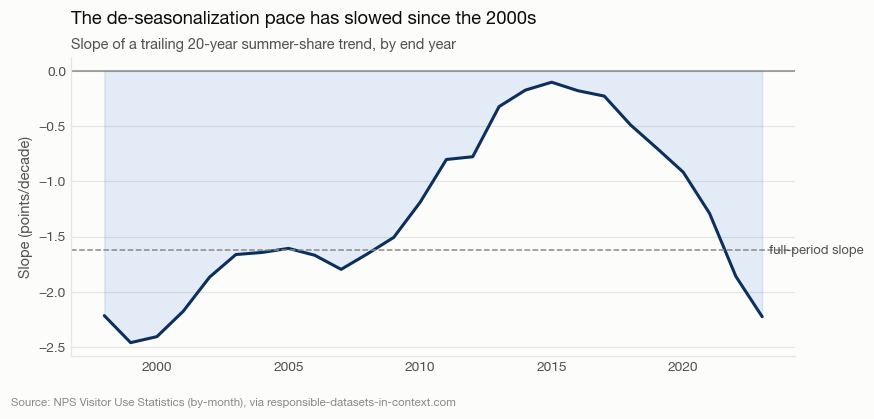

In [27]:
window = 20
rolling_slopes = {}
yrs = summer.index.to_numpy()
for end_year in range(yrs.min() + window - 1, yrs.max() + 1):
    win = summer[(summer.index > end_year - window) & (summer.index <= end_year)]
    if len(win) == window:
        rolling_slopes[end_year] = npdata.trend(win).slope * 100
rolling_slopes = pd.Series(rolling_slopes)

fig, ax = npviz.new_figure(8, 3.6)
ax.plot(rolling_slopes.index, rolling_slopes.values, color=npviz.DARK_BLUE, lw=2)
ax.fill_between(rolling_slopes.index, rolling_slopes.values, 0,
                 color=npviz.BLUE, alpha=0.12)
ax.axhline(0, color=npviz.TEXT_MUTED, lw=1)
ax.axhline(fit.slope * 100, color=npviz.TEXT_MUTED, lw=1, ls="--")
ax.text(rolling_slopes.index.max(), fit.slope * 100, "  full-period slope",
        fontsize=8.5, color=npviz.TEXT_SECONDARY, va="center")
npviz.title(ax, "The de-seasonalization pace has slowed since the 2000s",
            "Slope of a trailing 20-year summer-share trend, by end year")
ax.set_ylabel("Slope (points/decade)")
npviz.source_note(fig)
npviz.save(fig, "09_rolling_trend_slope")
plt.tight_layout()
plt.show()


The rolling slope is negative in every 20-year window, so the direction
never reverses — but its magnitude is far from constant. It weakens from the
late 1990s toward roughly zero by the mid-2010s, then swings sharply
negative again in windows ending after 2020. That last swing should not be
read as a behavioural re-acceleration: those windows all contain the
anomalous 2020–2021 closures, so part of it is mechanical. Set the
pandemic windows aside and the honest summary is that de-seasonalization was
fastest in the 1980s–90s and slowest around 2010–2017.

The choice of start year is the other decision that could be doing work,
since the series begins in 1979 for reasons of data availability rather than
theory:

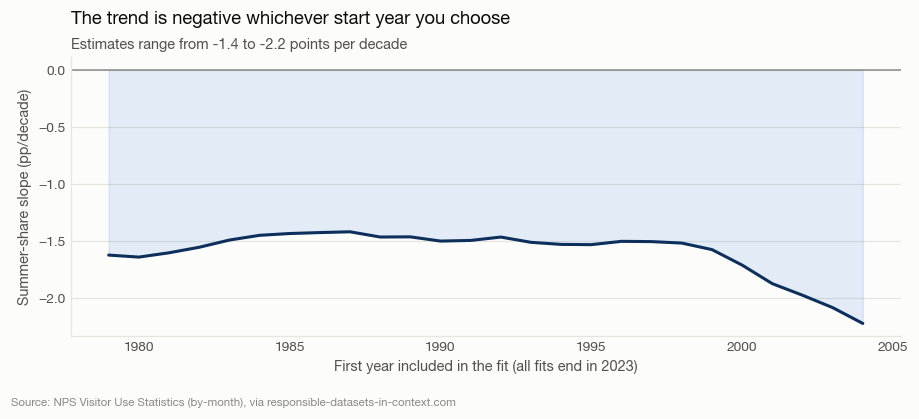

In [28]:
start_year_slopes = pd.Series({
    y0: npdata.trend(summer[summer.index >= y0]).slope * 100
    for y0 in range(1979, 2005)})

fig, ax = npviz.new_figure(8.4, 3.6)
ax.plot(start_year_slopes.index, start_year_slopes.values, color=npviz.DARK_BLUE, lw=2)
ax.fill_between(start_year_slopes.index, start_year_slopes.values, 0,
                color=npviz.BLUE, alpha=0.12)
ax.axhline(0, color=npviz.TEXT_MUTED, lw=1)
ax.set_xlabel("First year included in the fit (all fits end in 2023)")
ax.set_ylabel("Summer-share slope (pp/decade)")
npviz.title(ax, "The trend is negative whichever start year you choose",
            f"Estimates range from {start_year_slopes.max():.1f} to "
            f"{start_year_slopes.min():.1f} points per decade")
npviz.source_note(fig)
npviz.save(fig, "15_start_year_sensitivity")
plt.tight_layout()
plt.show()


Every start year from 1979 to 2004 yields a negative slope, ranging from
−1.4 to −2.2 points per decade. The estimate is flat and near −1.5 for any
start in the 1980s or 1990s and becomes *more* negative for later starts,
because shorter recent windows weight the pandemic years more heavily. The
sign is therefore not a choice we made; the precise magnitude partly is, and
the claim quotes the full-window figure rather than the most dramatic one.

Finally, the [2020 regional-recovery analysis](#Supporting-context) shows
the one large shock in the panel hitting regions unevenly, with different
recovery speeds through 2023. It is useful context for how volatile
year-to-year visitation is around these slow-moving trends, but as a single
event it is not treated as evidence for either half of the claim.

### Discussion

**What is genuinely surprising.** The headline number — a falling summer
share — sounds like a story about summer, and it is not. Summer visitation
grew 29% over the panel; it simply grew far more slowly than the other nine
months (+81%). Reporting only the share would invite a reader to conclude
that August has quietened down, when August is in fact busier than it has
ever been. The second surprise is *which* months absorbed the shift. A
warming-climate account predicts symmetric gains in the shoulder months;
instead March is the single biggest winner, ahead of December and November,
which points toward spring-break timing and the rise of desert and
Sun-Belt parks rather than a longer alpine hiking season. The third is the
null in Panel B above: de-seasonalization and the camping decline are
uncorrelated across parks, so what reads as one coherent lifestyle shift is
better described as two independent changes that happen to point the same
direction for the average visit.

**What is obvious but worth confirming.** That overall visitation grew, and
that summer still dominates, are both unremarkable — but they matter as
sanity checks. Even after 45 years of de-seasonalization, roughly 44% of
visits still fall in three of twelve months, about 1.8 times what a flat
calendar would give. The system has become less seasonal, not unseasonal,
and nothing here suggests the peak is going away.

**What the analysis can and cannot say about mechanism.** The data support
the *description* strongly and the *explanation* weakly. We can rule out
several alternatives: the pattern is not an aggregation artifact (it holds
within parks, with fixed effects), not a composition effect from parks
entering the file late (the balanced panel matches), not a ceiling effect
(starting concentration does not predict the trend), not a pandemic artifact
(it holds excluding 2020–2021), and the camping decline is not a denominator
effect (overnight stays fell 37% in absolute terms). What we cannot do is
identify a cause. Campground capacity is essentially fixed while visits
grew 55%, so some of the camping decline could be rationing rather than
changing preference — and this dataset contains no capacity or reservation
data with which to separate the two. Likewise we cannot distinguish warmer
shoulder seasons from cheaper off-peak travel, changing demographics, or
timed-entry policies, all of which would leave a similar footprint in
monthly counts.

**What would change our mind.** The de-seasonalization claim would be in
trouble if campground or road-closure records showed that parks simply
opened for more of the year over this period, which would make the pattern a
supply artifact rather than a behavioural one; if NPS counting methodology
changed in a way that improved off-season coverage specifically, the same
would apply, and the data essay's account of formula-based, park-specific
adjustments means we cannot fully exclude it. The camping claim would be in
trouble if campground capacity fell over the period, since a declining rate
would then be mostly mechanical. Both are checkable against records outside
this file, and both are listed as next steps.

**Generalizability.** We would extend these findings along some dimensions
and not others. *Across time:* the direction is the safer bet than the rate.
Both series are negative in every rolling window and under every start year,
but the pace varies by a factor of two and slowed markedly in the 2010s, so
extrapolating −1.6 points/decade far into the future would overstate the
change; the honest forecast is continued, decelerating de-seasonalization.
*Across place:* not uniformly. The effect is three times larger in the
Intermountain region than in Alaska and is absent in the Northeast, so this
is primarily a statement about national and Western visitation. *Across park
types:* we would not extend it at all. The file contains only the 63 units
designated "National Park"; monuments, seashores, recreation areas and
historic sites are excluded and plausibly behave differently, with many
already dominated by short local day visits that leave little room for the
same shift. *Across visitation habits:* the findings describe *counted
recreation visits*, which per the data essay exclude commuters, researchers,
staff and Indigenous residents of park lands, and which under-represent
communities with less access to parks in the first place. The claim is about
how counted visits are distributed across the calendar, and should not be
read as a claim about how all people relate to these places.

## Potential topics for further exploration <a id='Further-topics'></a>

Beyond the primary claim above, the by-month panel supports several other
lines of analysis we did not pursue in depth here. Listed roughly in order
of how promising they looked during EDA:

1. **Weekday/weekend and holiday timing** — this file is monthly, so it
   can't speak to within-month timing, but a day-level NPS dataset could
   test whether the de-seasonalization in Finding 1 is really "more
   shoulder-season trips" or "more long weekends," which have different
   policy implications for park staffing.
2. **Climate as a driver.** Overlaying regional temperature/precipitation
   anomalies (e.g. NOAA climate divisions) against each park's peak-month
   shift could test whether the alpine parks trending toward *more* summer
   concentration (Finding 1's robustness section) are responding to
   lengthening warm seasons, rather than just growing tourism.
3. **Camping supply constraints.** Cross-referencing NPS campground
   capacity/reservation data (e.g. Recreation.gov booking data) against the
   `TentCampers`/`RVCampers` rate would let us separate a demand-side
   change (Finding 2) from a supply-side ceiling — right now we can only
   flag this as a limitation, not resolve it.
4. **Fee and reservation-system changes.** Several high-traffic parks
   introduced timed-entry reservations in the years around 2020–2021
   (e.g. Zion, Glacier); a park-level event-study around each policy's
   introduction date could test whether de-seasonalization is partly a
   policy effect rather than an organic behavior shift.
5. **NonRecreationVisits as a validity check.** We did not use this column;
   comparing its trend to `RecreationVisits` could sanity-check whether
   counting methodology itself has drifted over the 45-year window (see
   the measurement caveat in Limitations).
6. **Extending past 2023.** The data essay notes 2024 annual figures were
   reportedly suppressed after release; if a by-month 2024–2025 extract
   becomes available, re-running Finding 1's trend would test whether the
   de-seasonalization continued, plateaued, or reversed post-pandemic.
